<a href="https://colab.research.google.com/github/norahalshamsan/DS-Project/blob/main/Copy_of_Lab_7_NN_Multi_class_classification_with_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#@title Copyright 2020 Google LLC. Double-click here for license information.
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Yann LeCun and Corinna Cortes hold the copyright of MNIST dataset,
# which is a derivative work from original NIST datasets.
# MNIST dataset is made available under the terms of the
# Creative Commons Attribution-Share Alike 3.0 license.

# Multi-Class Classification

This Colab explores multi-class classification problems through the classic MNIST dataset.

## Learning Objectives:

After doing this Colab, you'll know how to do the following:

  * Understand the classic MNIST problem.
  * Create a neural network that performs multi-class classification.
  * Tune the neural network.

This lab introduces image classification with machine learning.

## The Dataset
  
This MNIST dataset contains a lot of examples:

* The MNIST training set contains 60,000 examples.
* The MNIST test set contains 10,000 examples.

Each example contains a pixel map showing how a person wrote a digit. For example, the following images shows how a person wrote the digit `1` and how that digit might be represented in a 14x14 pixel map (after the input data is normalized).

![Two images. The first image shows a somewhat fuzzy digit one. The second image shows a 14x14 floating-point array in which most of the cells contain 0 but a few cells contain values between 0.0 and 1.0. The pattern of nonzero values corresponds to the image of the fuzzy digit in the first image.](https://www.tensorflow.org/images/MNIST-Matrix.png)

Each example in the MNIST dataset consists of:

* A label specified by a [rater](https://developers.google.com/machine-learning/glossary/#rater).  Each label must be an integer from 0 to 9.  For example, in the preceding image, the rater would almost certainly assign the label `1` to the example.
* A 28x28 pixel map, where each pixel is an integer between 0 and 255. The pixel values are on a gray scale in which 0 represents white, 255 represents black, and values between 0 and 255 represent various shades of gray.  

This is a multi-class classification problem with 10 output classes, one for each digit.

## Import relevant modules

The following hidden code cell imports the necessary code to run the code in the rest of this Colaboratory.

In [2]:
#@title Import relevant modules
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers
from matplotlib import pyplot as plt

# The following lines adjust the granularity of reporting.
pd.options.display.max_rows = 10
pd.options.display.float_format = "{:.1f}".format

# The following line improves formatting when ouputting NumPy arrays.
np.set_printoptions(linewidth = 200)

## Load the dataset

`tf.keras` provides a set of convenience functions for loading well-known datasets. Each of these convenience functions does the following:

* Loads both the training set and the test set.
* Separates each set into features and labels.

The relevant convenience function for MNIST is called `mnist.load_data()`:

In [3]:
(x_train, y_train),(x_test, y_test) = tf.keras.datasets.mnist.load_data()


Notice that `mnist.load_data()` returned four separate values:

* `x_train` contains the training set's features.
* `y_train` contains the training set's labels.
* `x_test` contains the test set's features.
* `y_test` contains the test set's labels.

**Note:** The MNIST .csv training set is already shuffled.

## View the dataset

The .csv file for the California Housing Dataset contains column names (for example, `latitude`, `longitude`, `population`). By contrast, the .csv file for MNIST does not contain column names. Instead of column names, you use ordinal numbers to access different subsets of the MNIST dataset. In fact, it is probably best to think of `x_train` and `x_test` as three-dimensional NumPy arrays:  



In [4]:
# Output example #2917 of the training set.
x_train[2917]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0, 127, 100, 156, 239, 224, 177, 213, 159,  70,  13,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0, 110, 250, 254, 254, 254, 254, 254, 254, 254, 254, 184,  10,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0, 216, 254, 254, 254, 254, 254, 254, 254, 254, 254, 251,  54,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   3, 131, 197,  68, 137, 101,  83,  41,  70, 221, 254, 108,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  58, 254, 216,  11,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 110, 254, 254,  24,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   4,  83, 247, 254, 192,  10,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  37, 124, 254, 254, 250,  47,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 113, 178, 250, 254, 254, 254, 252, 178, 128,  50,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  69, 252, 254, 254, 254, 254, 254, 254, 254, 254, 153,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 141, 252, 254, 241, 241, 254, 247, 252, 254, 254, 153,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  68,  82,   5,   5,  82,  37,  65, 167, 254, 190,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 162, 254, 153,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1, 172, 253,  75,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 102, 254, 152,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  38, 230, 216,  20,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,  71, 222, 254, 142,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  66, 254, 254, 157,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   4,  34,  34,  78, 161, 226, 249, 254, 154,   6,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  96, 184, 254, 254, 254, 254, 254, 249,  93,   5,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0

Alternatively, you can call `matplotlib.pyplot.imshow` to interpret the preceding numeric array as an image.

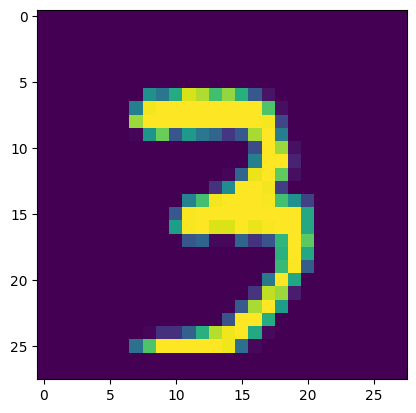

In [5]:
# Use false colors to visualize the array.
plt.imshow(x_train[2917])

In [6]:
# Output row #10 of example #2917.
x_train[2917][10]

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  58, 254, 216,  11,   0,   0,   0,   0,   0,   0,   0,   0], dtype=uint8)

In [7]:
# Output pixel #16 of row #10 of example #2900.
x_train[2900][10][16]

np.uint8(0)

### Evaluation Task 1: Normalize feature values

Complete the following code cell to map each feature value from its current representation (an integer between 0 and 255) to a floating-point value between 0 and 1.0. Store the floating-point values in `x_train_normalized` and `x_test_normalized`.

In [8]:
from sklearn.preprocessing import MinMaxScaler
x_train_normalized = x_train / 255.0
x_test_normalized = x_test / 255.0
print(x_train_normalized[2900][10]) # Output a normalized row

[0.         0.         0.         0.         0.         0.         0.         0.55294118 1.         0.66666667 0.11372549 0.         0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.         0.         0.         0.         0.        ]


## Define a plotting function

The following function plots an accuracy curve:

In [9]:
#@title Define the plotting function
def plot_curve(epochs, hist, list_of_metrics):
  """Plot a curve of one or more classification metrics vs. epoch."""
  # list_of_metrics should be one of the names shown in:
  # https://www.tensorflow.org/tutorials/structured_data/imbalanced_data#define_the_model_and_metrics

  plt.figure()
  plt.xlabel("Epoch")
  plt.ylabel("Value")

  for m in list_of_metrics:
    x = hist[m]
    plt.plot(epochs[1:], x[1:], label=m)

  plt.legend()

print("Loaded the plot_curve function.")

Loaded the plot_curve function.


## Part 1: Buidling Neural Network Model

### Create a neural network model

The `create_model` function defines the topography of the deep neural net, specifying the following:

* The number of [layers](https://developers.google.com/machine-learning/glossary/#layer) in the deep neural net.
* The number of [nodes](https://developers.google.com/machine-learning/glossary/#node) in each layer.
* Any [regularization](https://developers.google.com/machine-learning/glossary/#regularization) layers.

The `create_model` function also defines the [activation function](https://developers.google.com/machine-learning/glossary/#activation_function) of each layer.  The activation function of the output layer is [softmax](https://developers.google.com/machine-learning/glossary/#softmax), which will yield 10 different outputs for each example. Each of the 10 outputs provides the probability that the input example is a certain digit.

**Note:** Unlike several of the recent Colabs, this exercise does not define feature columns or a feature layer.  Instead, the model will train on the NumPy array.

In [10]:
def create_model(my_learning_rate):
  """Create and compile a deep neural net."""

  # All models in this course are sequential.
  model = tf.keras.models.Sequential()

  # The features are stored in a two-dimensional 28X28 array.
  # Flatten that two-dimensional array into a one-dimensional
  # 784-element array.
  model.add(tf.keras.layers.Flatten(input_shape=(28, 28)))

  # Define the first hidden layer.
  model.add(tf.keras.layers.Dense(units=32, activation='relu'))

  # Define a dropout regularization layer.
  model.add(tf.keras.layers.Dropout(rate=0.2))

  # Define the output layer. The units parameter is set to 10 because
  # the model must choose among 10 possible output values (representing
  # the digits from 0 to 9, inclusive).
  #
  # Don't change this layer.
  model.add(tf.keras.layers.Dense(units=10, activation='softmax'))

  # Construct the layers into a model that TensorFlow can execute.
  # Notice that the loss function for multi-class classification
  # is different than the loss function for binary classification.
  model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=my_learning_rate),
                loss="sparse_categorical_crossentropy",
                metrics=['accuracy'])

  return model


def train_model(model, train_features, train_label, epochs,
                batch_size=None, validation_split=0.1):
  """Train the model by feeding it data."""

  history = model.fit(x=train_features, y=train_label, batch_size=batch_size,
                      epochs=epochs, shuffle=True,
                      validation_split=validation_split)

  # To track the progression of training, gather a snapshot
  # of the model's metrics at each epoch.
  epochs = history.epoch
  hist = pd.DataFrame(history.history)

  return epochs, hist

### Training and Testing
Run the following code cell to invoke the preceding functions and actually train the model on the training set and test the model on the testing set.

**Note:** Due to several factors (for example, more examples and a more complex neural network) training MNIST might take longer than training the California Housing Dataset.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - accuracy: 0.5075 - loss: 1.5780 - val_accuracy: 0.7782 - val_loss: 0.8365
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.7544 - loss: 0.8029 - val_accuracy: 0.8635 - val_loss: 0.5054
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8228 - loss: 0.5841 - val_accuracy: 0.8927 - val_loss: 0.4000
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.8550 - loss: 0.4914 - val_accuracy: 0.9065 - val_loss: 0.3483
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.8716 - loss: 0.4411 - val_accuracy: 0.9149 - val_loss: 0.3154
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.8801 - loss: 0.4087 - val_accuracy: 0.9205 - val_loss: 0.2919
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.8891 - loss: 0.3796 - val_accuracy: 0.9248 - val_loss: 0.2744
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8951 - loss: 0.3634 - val_accuracy: 0.9287 - v

[0.14555789530277252, 0.9564999938011169]

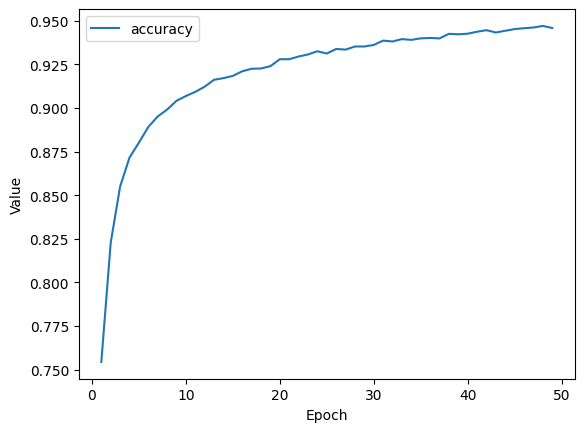

In [11]:
# The following variables are the hyperparameters.
learning_rate = 0.003
epochs = 50
batch_size = 4000
validation_split = 0.2

# Establish the model's topography.
my_model = create_model(learning_rate)

# Train the model on the normalized training set.
epochs, hist = train_model(my_model, x_train_normalized, y_train,
                           epochs, batch_size, validation_split)

# Plot a graph of the metric vs. epochs.
list_of_metrics_to_plot = ['accuracy']
plot_curve(epochs, hist, list_of_metrics_to_plot)

# Evaluate against the test set.
print("\n Evaluate the new model against the test set:")
my_model.evaluate(x=x_test_normalized, y=y_test, batch_size=batch_size)

### Evaluation Task 2: Optimize the model

We want to optimize the prevoius model using different values for the number of hidden layers, the number of nodes in each layer, and dropout regularization rate.

1. Create two different models, with following configurations:

* **Model 1:** One hidden layer of 256 nodes; no second hidden layer; dropout regularization rate of 0.4.

* **Model 2:** First hidden layer of 256 nodes; second hidden layer of 128 nodes; dropout regularization rate of 0.2.

2. Evaluate their performance on the test set using Accuracy.

3. Compare the performance of the two models with the previous model.


Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/step - accuracy: 0.6885 - loss: 1.0186 - val_accuracy: 0.8898 - val_loss: 0.3762
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - accuracy: 0.8737 - loss: 0.4187 - val_accuracy: 0.9208 - val_loss: 0.2787
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 0.9071 - loss: 0.3144 - val_accuracy: 0.9351 - val_loss: 0.2346
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.9235 - loss: 0.2631 - val_accuracy: 0.9429 - val_loss: 0.2006
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.9345 - loss: 0.2272 - val_accuracy: 0.9494 - val_loss: 0.1796
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - accuracy: 0.9420 - loss: 0.2028 - val_accuracy: 0.9538 - val_loss: 0.1623
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - accuracy: 0.9477 - loss: 0.1841 - val_accuracy: 0.9577 - val_loss: 0.1501
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 142ms/step - accuracy: 0.9513 - loss: 0.1682 - val_accuracy: 0.9601 -

[0.06633353233337402, 0.9804999828338623]

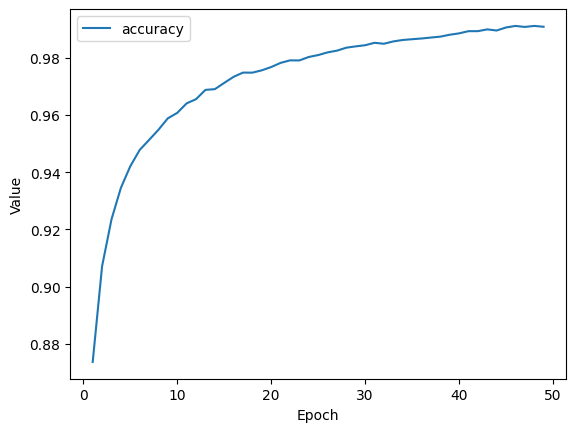

In [12]:
def create_model_1(my_learning_rate):
  model = tf.keras.models.Sequential()
  model.add(tf.keras.layers.Flatten(input_shape=(28, 28)))
  model.add(tf.keras.layers.Dense(units=256, activation='relu'))
  model.add(tf.keras.layers.Dropout(rate=0.4))
  model.add(tf.keras.layers.Dense(units=10, activation='softmax'))

  model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=my_learning_rate),
                loss="sparse_categorical_crossentropy",
                metrics=['accuracy'])
  return model

learning_rate = 0.003
epochs = 50
batch_size = 4000
validation_split = 0.2

model1 = create_model_1(learning_rate)
epochs1, hist1 = train_model(model1, x_train_normalized, y_train,
                            epochs, batch_size, validation_split)

plot_curve(epochs1, hist1, ['accuracy'])

print("\nEvaluate Model 1 on test set:")
model1.evaluate(x=x_test_normalized, y=y_test, batch_size=batch_size)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step - accuracy: 0.6850 - loss: 1.0589 - val_accuracy: 0.8997 - val_loss: 0.3458
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.8907 - loss: 0.3687 - val_accuracy: 0.9282 - val_loss: 0.2494
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - accuracy: 0.9240 - loss: 0.2559 - val_accuracy: 0.9433 - val_loss: 0.1943
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 151ms/step - accuracy: 0.9411 - loss: 0.2004 - val_accuracy: 0.9535 - val_loss: 0.1610
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 140ms/step - accuracy: 0.9525 - loss: 0.1613 - val_accuracy: 0.9575 - val_loss: 0.1430
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.9593 - loss: 0.1358 - val_accuracy: 0.9629 - val_loss: 0.1294
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - accuracy: 0.9652 - loss: 0.1178 - val_accuracy: 0.9645 - val_loss: 0.1187
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - accuracy: 0.9711 - loss: 0.0997 - val_accuracy: 0.9678 

[0.08969809859991074, 0.979200005531311]

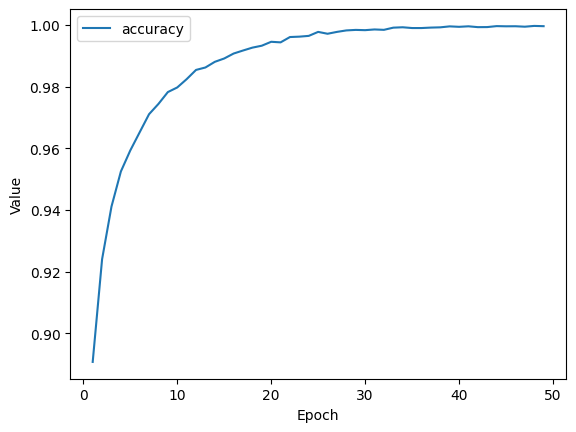

In [13]:
def create_model_2(my_learning_rate):
  model = tf.keras.models.Sequential()
  model.add(tf.keras.layers.Flatten(input_shape=(28, 28)))
  model.add(tf.keras.layers.Dense(units=256, activation='relu'))
  model.add(tf.keras.layers.Dense(units=128, activation='relu'))
  model.add(tf.keras.layers.Dropout(rate=0.2))
  model.add(tf.keras.layers.Dense(units=10, activation='softmax'))

  model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=my_learning_rate),
                loss="sparse_categorical_crossentropy",
                metrics=['accuracy'])
  return model

learning_rate = 0.003
epochs = 50
batch_size = 4000
validation_split = 0.2

model2 = create_model_2(learning_rate)
epochs2, hist2 = train_model(model2, x_train_normalized, y_train,
                            epochs, batch_size, validation_split)

plot_curve(epochs2, hist2, ['accuracy'])

print("\nEvaluate Model 2 on test set:")
model2.evaluate(x=x_test_normalized, y=y_test, batch_size=batch_size)

## Part 2: Hyperparameters Tuning using Cross-Validation

Now instead of trying different values by hand, we will use `GridSearchCV` from Scikit-Learn to try out several values for our hyperparameters and compare the results.

To do cross-validation, keras models can be used in `scikit-learn` by wrapping them with the `KerasClassifier` or `KerasRegressor` class from the module SciKeras.

You may need to run the command `pip install scikeras` first to install the module.

To use these wrappers, you must define a function that creates and returns your Keras sequential model, then pass this function to the model argument when constructing the `KerasClassifier` class.



In [14]:
!pip install scikeras ## to download and install scikeras package

In [15]:
# Force a complete reinstallation of scikeras and its dependencies
!pip install scikeras --force-reinstall


  Using cached scikeras-0.13.0-py3-none-any.whl.metadata (3.1 kB)
  Using cached keras-3.13.2-py3-none-any.whl.metadata (6.3 kB)
  Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached numpy-2.4.2-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached rich-14.3.3-py3-none-any.whl.metadata (18 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
  Using cached h5py-3.15.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (3.0 kB)
  Using cached optree-0.19.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (34 kB)
  Using cached ml_dtypes-0.5.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (8.9 kB)
  Using cached packaging-26.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached scipy-1.17.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86

In [16]:
import numpy
from sklearn.model_selection import GridSearchCV
from scikeras.wrappers import KerasClassifier


**Note:** Cross-validation in neural networks is computationally expensive. Think before you experiment! Multiply the number of features you are validating on to see how many combinations there are. Each combination is evaluated using the k-fold cross-validation (k is a parameter we choose).


### Tuning batch size and number of epochs

We will now perform a GridSearch for the batch size and the number of epochs.Their different values are specified in a dictionary and passed to GridSearchCV.

In [18]:
# create KerasClassifier model
model = KerasClassifier(model=create_model, my_learning_rate=0.003, verbose=2)

# define the grid search parameters
batch_size = [128, 512]
epochs = [10, 20]
param_grid = dict(batch_size=batch_size, epochs=epochs)

## grid search for the batch size and number of epochs
grid = GridSearchCV(estimator=model, param_grid=param_grid, n_jobs=-1, cv=3, verbose=2)
grid_result = grid.fit(x_train_normalized, y_train)

# summarize results
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

Fitting 3 folds for each of 4 candidates, totalling 12 fits


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
469/469 - 2s - 5ms/step - accuracy: 0.8582 - loss: 0.4686
Epoch 2/20
469/469 - 2s - 5ms/step - accuracy: 0.9149 - loss: 0.2830
Epoch 3/20
469/469 - 1s - 3ms/step - accuracy: 0.9248 - loss: 0.2471
Epoch 4/20
469/469 - 1s - 3ms/step - accuracy: 0.9309 - loss: 0.2227
Epoch 5/20
469/469 - 3s - 7ms/step - accuracy: 0.9348 - loss: 0.2093
Epoch 6/20
469/469 - 1s - 3ms/step - accuracy: 0.9387 - loss: 0.1951
Epoch 7/20
469/469 - 1s - 3ms/step - accuracy: 0.9415 - loss: 0.1898
Epoch 8/20
469/469 - 1s - 3ms/step - accuracy: 0.9427 - loss: 0.1819
Epoch 9/20
469/469 - 1s - 3ms/step - accuracy: 0.9442 - loss: 0.1771
Epoch 10/20
469/469 - 1s - 3ms/step - accuracy: 0.9455 - loss: 0.1714
Epoch 11/20
469/469 - 1s - 3ms/step - accuracy: 0.9453 - loss: 0.1712
Epoch 12/20
469/469 - 1s - 3ms/step - accuracy: 0.9482 - loss: 0.1656
Epoch 13/20
469/469 - 3s - 6ms/step - accuracy: 0.9480 - loss: 0.1596
Epoch 14/20
469/469 - 1s - 3ms/step - accuracy: 0.9487 - loss: 0.1619
Epoch 15/20
469/469 - 1s - 3m

### Tuning the Number of Neurons in the hidden layers

Now, the hyperparameter that we will try to optimize via cross-validation is the number of neurons in the first hidden layer.

In [19]:
# First we need to create a function that creates the model (required for KerasClassifier)
# while accepting the hyperparameters we want to tune
# we also pass some default values such as my_learning_rate

def create_model_n(neurons, my_learning_rate=0.003):

# create model

  # All models in this course are sequential.
  model = tf.keras.models.Sequential()

  # The features are stored in a two-dimensional 28X28 array.
  # Flatten that two-dimensional array into a one-dimensional
  # 784-element array.
  model.add(tf.keras.layers.Flatten(input_shape=(28, 28)))

  # Define the first hidden layer.
  model.add(tf.keras.layers.Dense(units=neurons, activation='relu'))

  # Define a dropout regularization layer.
  model.add(tf.keras.layers.Dropout(rate=0.2))

  # Define the output layer. The units parameter is set to 10 because
  # the model must choose among 10 possible output values (representing
  # the digits from 0 to 9, inclusive).
  #
  # Don't change this layer.
  model.add(tf.keras.layers.Dense(units=10, activation='softmax'))

# Compile model

  # Construct the layers into a model that TensorFlow can execute.
  # Notice that the loss function for multi-class classification
  # is different than the loss function for binary classification.
  model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=my_learning_rate),
                loss="sparse_categorical_crossentropy",
                metrics=['accuracy'])

  return model

In [20]:
# create KerasClassifier model
model = KerasClassifier(model=create_model_n, epochs=50, batch_size=4000, verbose=0)

# define the grid search parameters
neurons = [32,64,128]
param_grid = dict(model__neurons=neurons)

## grid search for the number of nuerons in the first hidden layer.
grid = GridSearchCV(estimator=model, param_grid=param_grid, n_jobs=-1, cv=3)
grid_result = grid.fit(x_train_normalized, y_train)

# summarize results
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Best: 0.972567 using {'model__neurons': 128}
0.951017 (0.001455) with: {'model__neurons': 32}
0.966650 (0.001560) with: {'model__neurons': 64}
0.972567 (0.001199) with: {'model__neurons': 128}


### Evaluation Task 3: Tuning the Activtion Function in the hidden layers

**Optimize the model by trying differnt activation functions for the first hidden layer.**



In [21]:
# First, write a function  that creates and compiles a neural network model (required for KerasClassifier)
# while accepting the hyperparameters you want to tune, call it create_model_a
# activation functions: 'relu', 'sigmoid', 'linear'

def create_model_a(activation, my_learning_rate=0.003):
  model = tf.keras.models.Sequential()
  model.add(tf.keras.layers.Flatten(input_shape=(28, 28)))

  # choose activation for the first hidden layer
  model.add(tf.keras.layers.Dense(units=256, activation=activation))

  model.add(tf.keras.layers.Dropout(rate=0.2))
  model.add(tf.keras.layers.Dense(units=10, activation='softmax'))

  model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=my_learning_rate),
                loss="sparse_categorical_crossentropy",
                metrics=['accuracy'])
  return model



In [22]:
# create KerasClassifier model
model = KerasClassifier(model=create_model_a, epochs=20, batch_size=512, verbose=0)

# define the grid search parameters
activations = ['relu', 'sigmoid', 'linear']
param_grid = dict(model__activation=activations)

# grid search for activation function
grid = GridSearchCV(estimator=model, param_grid=param_grid, n_jobs=-1, cv=3)
grid_result = grid.fit(x_train_normalized, y_train)

# summarize results
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Best: 0.976900 using {'model__activation': 'relu'}
0.976900 (0.000738) with: {'model__activation': 'relu'}
0.971600 (0.001111) with: {'model__activation': 'sigmoid'}
0.914283 (0.001195) with: {'model__activation': 'linear'}
